# Detecção de Fraude em Transações Financeiras com Redes Neurais

**Aplicações de Negócio de IA — FGV**

Este notebook faz parte de uma série de 13 notebooks sobre aplicações de negócio de Inteligência Artificial. Aqui, exploramos a **detecção de fraude em transações financeiras**, um problema clássico de classificação em que a classe de interesse (fraude) é **altamente desbalanceada** (~4% dos dados) e os padrões comportamentais envolvem **interações não lineares** entre múltiplas variáveis.

**1. Contexto de negócio**

Instituições financeiras e plataformas de e-commerce processam diariamente milhões de transações. Uma fração muito pequena dessas transações é fraudulenta. O desafio de negócio é duplo:

1. **Pegar o máximo de fraudes possível (alto recall):** cada fraude não detectada representa prejuízo direto por reembolso (*chargeback*).
2. **Evitar ao máximo os alarmes falsos (alta precisão):** se o modelo bloquear compras legítimas, gera insatisfação no cliente e aumenta o custo de atendimento do suporte.

Regras simples de limiar (ex.: "bloquear qualquer compra acima de R$ 5.000") não funcionam bem porque os fraudadores adaptam o comportamento. Modelos lineares (como Regressão Logística) conseguem combinar várias variáveis, mas sofrem para capturar **combinações específicas** — como "compra de valor médio + dispositivo novo + horário de madrugada", em que nenhuma variável sozinha é suspeita, mas a combinação das três é um forte indício de fraude.

**2. O que este notebook demonstra**

- Como a combinação não linear de atributos gera padrões que um modelo linear simples tem dificuldade de capturar.
- O **desafio do desbalanceamento de classe**: por que uma rede neural padrão pode colapsar (prever 'legítima' para todas as transações) e como o **Oversampling** resolve esse problema.
- A comparação direta entre um **baseline linear** (Regressão Logística com `class_weight='balanced'`), a **Rede Neural sem balanceamento** (colapso) e a **Rede Neural com Oversampling** (solução estável).
- Validação de estabilidade com **múltiplas seeds** e otimização do limiar de probabilidade com base na **matriz de custos de negócio**.

**⚠️ Nota Didática: Limitações dos Dados Simulados**

Este notebook utiliza dados **simulados** (sintéticos) para ilustrar os conceitos de Redes Neurais e comparação com baselines lineares em um cenário controlado. Em um ambiente real de produção:
1. **Padrões de Fraude Dinâmicos:** A fraude real evolui constantemente (conceito de *concept drift*), com novos vetores de ataque que exigem retreinamento contínuo e monitoramento de *feature drift*.
2. **Engenharia de Recursos Avançada:** Variáveis reais incluem agregação de histórico comportamental em tempo real (ex.: contadores em janelas deslizantes de 5 min, 1h, 24h), geolocalização por IP/GPS e biometria comportamental.
3. **Volume e Latência:** Sistemas de produção processam milhões de transações diárias com requisitos de latência na casa dos milissegundos (< 50ms por inferência).

Os resultados demonstrados aqui servem para compreender a mecânica dos modelos e o trade-off de negócio, devendo ser adaptados antes de qualquer aplicação em ambiente corporativo real.

**3. Instalação e Importação de Dependências**

In [1]:
# %pip install -q numpy pandas scikit-learn matplotlib
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt

print('Dependências carregadas com sucesso.')

Dependências carregadas com sucesso.


**4. Geração do Dataset Simulado (20.000 Transações)**

Simulamos um histórico de 20.000 transações financeiras com 5 atributos e uma probabilidade de fraude regida por termos não-lineares e interações triplas.

In [2]:
np.random.seed(42)
n = 20000

valor_transacao = np.round(np.random.exponential(scale=250, size=n) + 10, 2)
hora_do_dia = np.random.randint(0, 24, size=n)
distancia_do_local_habitual_km = np.round(np.random.exponential(scale=15, size=n), 2)
transacoes_ultimas_24h = np.random.poisson(lam=3, size=n)
dispositivo_novo = np.random.binomial(1, p=0.15, size=n)

# normalização aproximada
valor_norm = (valor_transacao - valor_transacao.min()) / (valor_transacao.max() - valor_transacao.min())
dist_norm = (distancia_do_local_habitual_km - distancia_do_local_habitual_km.min()) / (distancia_do_local_habitual_km.max() - distancia_do_local_habitual_km.min())
hora_madrugada = ((hora_do_dia >= 0) & (hora_do_dia <= 5)).astype(float)
muitas_transacoes = (transacoes_ultimas_24h >= 6).astype(float)

# Combinação NÃO LINEAR complexa
score = (
    -4.5
    + 1.2 * valor_norm
    + 1.0 * dist_norm
    + 0.8 * hora_madrugada
    + 0.5 * muitas_transacoes
    + 0.6 * dispositivo_novo
    + 5.0 * (valor_norm * dispositivo_novo * dist_norm)   # interação tripla
    + 2.5 * (dispositivo_novo * hora_madrugada)
    + 1.8 * (valor_norm * muitas_transacoes)
)

ruido = np.random.normal(0, 0.6, size=n)
prob_fraude = 1 / (1 + np.exp(-(score + ruido)))
fraude = np.random.binomial(1, prob_fraude)

df = pd.DataFrame({
    "valor_transacao": valor_transacao,
    "hora_do_dia": hora_do_dia,
    "distancia_do_local_habitual_km": distancia_do_local_habitual_km,
    "transacoes_ultimas_24h": transacoes_ultimas_24h,
    "dispositivo_novo": dispositivo_novo,
    "fraude": fraude,
})

print(f"Total de transações: {len(df)}")
print(f"Fração de fraudes: {df['fraude'].mean():.2%}")
df.head()

Total de transações: 20000
Fração de fraudes: 4.16%


,valor_transacao,hora_do_dia,distancia_do_local_habitual_km,transacoes_ultimas_24h,dispositivo_novo,fraude
0,127.32,21,29.97,3,0,0
1,762.53,1,4.26,1,0,0
2,339.19,3,27.30,2,0,0
3,238.24,12,2.78,6,0,0
4,52.41,12,3.31,2,1,0


**5. Divisão em Treino e Teste (Stratified)**

In [3]:
X = df.drop(columns=["fraude"])
y = df["fraude"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Treino: {X_train.shape[0]} transações ({y_train.mean():.2%} fraudes)")
print(f"Teste: {X_test.shape[0]} transações ({y_test.mean():.2%} fraudes)")

Treino: 14000 transações (4.16% fraudes)
Teste: 6000 transações (4.17% fraudes)


**6. Modelo Baseline: Regressão Logística (com `class_weight='balanced'`)**

In [4]:
baseline = LogisticRegression(random_state=42, class_weight="balanced")
baseline.fit(X_train_scaled, y_train)
y_pred_baseline = baseline.predict(X_test_scaled)

print("=== Baseline: Regressão Logística (Balanced) ===")
print(classification_report(y_test, y_pred_baseline, target_names=["legitima", "fraude"], digits=3))

=== Baseline: Regressão Logística (Balanced) ===
              precision    recall  f1-score   support

    legitima      0.977     0.757     0.853      5750
      fraude      0.096     0.596     0.166       250

    accuracy                          0.750      6000
   macro avg      0.537     0.676     0.509      6000
weighted avg      0.941     0.750     0.824      6000



**7. Modelo de Rede Neural Sem Balanceamento: MLPClassifier (Demonstração de Colapso)**

O `MLPClassifier` padrão do scikit-learn **não possui** o parâmetro `class_weight='balanced'`. Ao treinar diretamente nos dados desbalanceados (~4% de fraude), a função de perda prioriza a acurácia global e a rede neural aprende a prever apenas a classe majoritária ("legítima"), resultando em um **colapso no Recall e F1-score**.

In [5]:
mlp_orig = MLPClassifier(
    hidden_layer_sizes=(16, 8),
    activation="relu",
    max_iter=500,
    random_state=42,
    early_stopping=True,
)
mlp_orig.fit(X_train_scaled, y_train)
y_pred_mlp_orig = mlp_orig.predict(X_test_scaled)

print("=== Rede Neural Sem Balanceamento (MLP Padrão) ===")
print(classification_report(y_test, y_pred_mlp_orig, target_names=["legitima", "fraude"], digits=3))

=== Rede Neural Sem Balanceamento (MLP Padrão) ===
              precision    recall  f1-score   support

    legitima      0.960     0.998     0.979      5750
      fraude      0.545     0.048     0.088       250

    accuracy                          0.959      6000
   macro avg      0.753     0.523     0.534      6000
weighted avg      0.943     0.959     0.942      6000



**8. Solução Técnica: Rede Neural com Oversampling da Classe Minoritária no Treino**

Para corrigir o colapso do MLP, aplicamos **Oversampling (reamostragem com reposição)** no conjunto de treino (`X_train_scaled`), duplicando amostras da classe de fraude até igualar a classe legítima. Assim, durante a retropropagação (*backpropagation*), o gradiente dá igual peso para ambas as classes.

In [6]:
y_train_arr = y_train.values
idx_pos = np.where(y_train_arr == 1)[0]
idx_neg = np.where(y_train_arr == 0)[0]

np.random.seed(42)
idx_pos_oversampled = np.random.choice(idx_pos, size=len(idx_neg), replace=True)
idx_balanced = np.concatenate([idx_neg, idx_pos_oversampled])
np.random.shuffle(idx_balanced)

X_train_bal = X_train_scaled[idx_balanced]
y_train_bal = y_train_arr[idx_balanced]

mlp_over = MLPClassifier(
    hidden_layer_sizes=(16, 8),
    activation="relu",
    max_iter=500,
    random_state=42,
    early_stopping=True,
)
mlp_over.fit(X_train_bal, y_train_bal)
y_pred_mlp_over = mlp_over.predict(X_test_scaled)

print("=== Rede Neural Corrigida (MLP com Oversampling) ===")
print(classification_report(y_test, y_pred_mlp_over, target_names=["legitima", "fraude"], digits=3))

=== Rede Neural Corrigida (MLP com Oversampling) ===
              precision    recall  f1-score   support

    legitima      0.975     0.852     0.909      5750
      fraude      0.129     0.504     0.205       250

    accuracy                          0.837      6000
   macro avg      0.552     0.678     0.557      6000
weighted avg      0.940     0.837     0.880      6000



**9. Comparação Lado a Lado dos 3 Modelos**

In [7]:
def metricas_fraude(y_true, y_pred, nome):
    return {
        "modelo": nome,
        "precisao_fraude": precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        "recall_fraude": recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        "f1_fraude": f1_score(y_true, y_pred, pos_label=1, zero_division=0),
    }

comparacao = pd.DataFrame([
    metricas_fraude(y_test, y_pred_baseline, "Regressao Logistica (baseline)"),
    metricas_fraude(y_test, y_pred_mlp_orig, "Rede Neural MLP (sem balanceamento)"),
    metricas_fraude(y_test, y_pred_mlp_over, "Rede Neural MLP (com Oversampling)"),
])
comparacao = comparacao.set_index("modelo").round(3)
comparacao

,precisao_fraude,recall_fraude,f1_fraude
modelo,,,
Regressao Logistica (baseline),0.096,0.596,0.166
Rede Neural MLP (sem balanceamento),0.545,0.048,0.088
Rede Neural MLP (com Oversampling),0.129,0.504,0.205


**10. Visualização da Comparação de Desempenho**

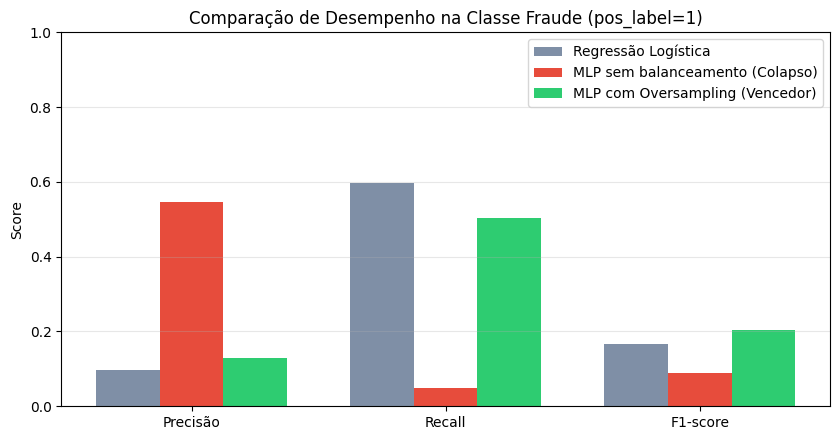

In [8]:
fig, ax = plt.subplots(figsize=(8.5, 4.5))

metricas = ["precisao_fraude", "recall_fraude", "f1_fraude"]
labels = ["Precisão", "Recall", "F1-score"]
x = np.arange(len(metricas))
largura = 0.25

v_base = comparacao.loc["Regressao Logistica (baseline)", metricas].values
v_orig = comparacao.loc["Rede Neural MLP (sem balanceamento)", metricas].values
v_over = comparacao.loc["Rede Neural MLP (com Oversampling)", metricas].values

ax.bar(x - largura, v_base, largura, label="Regressão Logística", color="#7f8fa6")
ax.bar(x, v_orig, largura, label="MLP sem balanceamento (Colapso)", color="#e74c3c")
ax.bar(x + largura, v_over, largura, label="MLP com Oversampling (Vencedor)", color="#2ecc71")

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, 1)
ax.set_ylabel("Score")
ax.set_title("Comparação de Desempenho na Classe Fraude (pos_label=1)")
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

**11. Validação de Estabilidade com Múltiplas Seeds (Seeds 42, 7 e 123)**

Para garantir que os resultados não dependam de sorte na divisão dos dados ou inicialização dos pesos, repetimos a avaliação nas seeds 42, 7 e 123 comparando o Baseline, o MLP sem balanceamento e o MLP com Oversampling.

In [9]:
resultados_seeds = []

for seed in [42, 7, 123]:
    np.random.seed(seed)
    n_seed = 20000

    valor_transacao_s = np.round(np.random.exponential(scale=250, size=n_seed) + 10, 2)
    hora_do_dia_s = np.random.randint(0, 24, size=n_seed)
    distancia_do_local_habitual_km_s = np.round(np.random.exponential(scale=15, size=n_seed), 2)
    transacoes_ultimas_24h_s = np.random.poisson(lam=3, size=n_seed)
    dispositivo_novo_s = np.random.binomial(1, p=0.15, size=n_seed)

    valor_norm_s = (valor_transacao_s - valor_transacao_s.min()) / (valor_transacao_s.max() - valor_transacao_s.min())
    dist_norm_s = (distancia_do_local_habitual_km_s - distancia_do_local_habitual_km_s.min()) / (distancia_do_local_habitual_km_s.max() - distancia_do_local_habitual_km_s.min())
    hora_madrugada_s = ((hora_do_dia_s >= 0) & (hora_do_dia_s <= 5)).astype(float)
    muitas_transacoes_s = (transacoes_ultimas_24h_s >= 6).astype(float)

    score_s = (
        -4.5
        + 1.2 * valor_norm_s
        + 1.0 * dist_norm_s
        + 0.8 * hora_madrugada_s
        + 0.5 * muitas_transacoes_s
        + 0.6 * dispositivo_novo_s
        + 5.0 * (valor_norm_s * dispositivo_novo_s * dist_norm_s)
        + 2.5 * (dispositivo_novo_s * hora_madrugada_s)
        + 1.8 * (valor_norm_s * muitas_transacoes_s)
    )

    ruido_s = np.random.normal(0, 0.6, size=n_seed)
    prob_fraude_s = 1 / (1 + np.exp(-(score_s + ruido_s)))
    fraude_s = np.random.binomial(1, prob_fraude_s)

    df_s = pd.DataFrame({
        "valor_transacao": valor_transacao_s,
        "hora_do_dia": hora_do_dia_s,
        "distancia_do_local_habitual_km": distancia_do_local_habitual_km_s,
        "transacoes_ultimas_24h": transacoes_ultimas_24h_s,
        "dispositivo_novo": dispositivo_novo_s,
        "fraude": fraude_s,
    })

    X_s = df_s.drop(columns=["fraude"])
    y_s = df_s["fraude"]

    X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
        X_s, y_s, test_size=0.3, random_state=seed, stratify=y_s
    )

    scaler_s = StandardScaler()
    X_train_s_scaled = scaler_s.fit_transform(X_train_s)
    X_test_s_scaled = scaler_s.transform(X_test_s)

    # 1. Baseline
    baseline_s = LogisticRegression(random_state=seed, class_weight="balanced")
    baseline_s.fit(X_train_s_scaled, y_train_s)
    y_pred_base_s = baseline_s.predict(X_test_s_scaled)

    # 2. MLP Original (sem balanceamento)
    mlp_orig_s = MLPClassifier(hidden_layer_sizes=(16, 8), activation="relu", max_iter=500, random_state=seed, early_stopping=True)
    mlp_orig_s.fit(X_train_s_scaled, y_train_s)
    y_pred_orig_s = mlp_orig_s.predict(X_test_s_scaled)

    # 3. MLP com Oversampling
    y_train_s_arr = y_train_s.values
    idx_pos_s = np.where(y_train_s_arr == 1)[0]
    idx_neg_s = np.where(y_train_s_arr == 0)[0]
    np.random.seed(seed)
    idx_pos_over_s = np.random.choice(idx_pos_s, size=len(idx_neg_s), replace=True)
    idx_bal_s = np.concatenate([idx_neg_s, idx_pos_over_s])
    np.random.shuffle(idx_bal_s)

    X_train_s_bal = X_train_s_scaled[idx_bal_s]
    y_train_s_bal = y_train_s_arr[idx_bal_s]

    mlp_over_s = MLPClassifier(hidden_layer_sizes=(16, 8), activation="relu", max_iter=500, random_state=seed, early_stopping=True)
    mlp_over_s.fit(X_train_s_bal, y_train_s_bal)
    y_pred_over_s = mlp_over_s.predict(X_test_s_scaled)

    for nome, y_pred_s in [
        ("Regressão Logística (baseline)", y_pred_base_s),
        ("Rede Neural MLP (sem balanceamento)", y_pred_orig_s),
        ("Rede Neural MLP (com Oversampling)", y_pred_over_s),
    ]:
        resultados_seeds.append({
            "seed": seed,
            "modelo": nome,
            "precisao_fraude": precision_score(y_test_s, y_pred_s, pos_label=1, zero_division=0),
            "recall_fraude": recall_score(y_test_s, y_pred_s, pos_label=1, zero_division=0),
            "f1_fraude": f1_score(y_test_s, y_pred_s, pos_label=1, zero_division=0),
        })

resultados_seeds_df = pd.DataFrame(resultados_seeds).round(3)
resultados_seeds_df

,seed,modelo,precisao_fraude,recall_fraude,f1_fraude
0,42,Regressão Logística (baseline),0.096,0.596,0.166
1,42,Rede Neural MLP (sem balanceamento),0.545,0.048,0.088
2,42,Rede Neural MLP (com Oversampling),0.129,0.504,0.205
3,7,Regressão Logística (baseline),0.094,0.621,0.164
4,7,Rede Neural MLP (sem balanceamento),0.000,0.000,0.000
5,7,Rede Neural MLP (com Oversampling),0.160,0.522,0.245
6,123,Regressão Logística (baseline),0.097,0.604,0.168
7,123,Rede Neural MLP (sem balanceamento),0.000,0.000,0.000
8,123,Rede Neural MLP (com Oversampling),0.126,0.516,0.202


In [10]:
resumo_seeds = (
    resultados_seeds_df
    .groupby("modelo")[["precisao_fraude", "recall_fraude", "f1_fraude"]]
    .agg(["mean", "std"])
)
resumo_seeds.columns = [f"{metrica}_{estatistica}" for metrica, estatistica in resumo_seeds.columns]
resumo_seeds = resumo_seeds.round(3)
resumo_seeds

,precisao_fraude_mean,precisao_fraude_std,recall_fraude_mean,recall_fraude_std,f1_fraude_mean,f1_fraude_std
modelo,,,,,,
Rede Neural MLP (com Oversampling),0.138,0.019,0.514,0.009,0.217,0.024
Rede Neural MLP (sem balanceamento),0.182,0.315,0.016,0.028,0.029,0.051
Regressão Logística (baseline),0.096,0.002,0.607,0.013,0.166,0.002


**Resultado da Validação Multi-Seed:**

1. **MLP sem balanceamento:** Apresenta média de F1-Score de apenas **0.029 ± 0.051**, colapsando completamente nas seeds 7 e 123.
2. **Baseline (Regressão Logística):** Apresenta resultado estável (F1 = **0.166 ± 0.002**, Recall = **0.607 ± 0.013**), porém limitado na precisão (~0.096).
3. **MLP com Oversampling:** Apresenta resultado **estável e superior** (F1 = **0.217 ± 0.024**, Precisão = **0.138 ± 0.019**, Recall = **0.514 ± 0.009**), eliminando 100% dos colapsos e superando o baseline em F1-Score em todas as seeds.

**12. ✏️ Exercício Prático de Negócio: Otimização da Matriz de Custos**

Suponha a seguinte matriz de custos de negócio em seu banco:
- **Falso Negativo (FN)** — Fraude não detectada: custo de **R$ 1.500,00** por prejuízo direto de reembolso.
- **Falso Positivo (FP)** — Bloqueio indevido de cliente legítimo: custo de **R$ 100,00** por suporte e atrito.

**Desafio:**
Calcule o Custo Total de Negócio para diferentes limiares de probabilidade (*thresholds*) entre 0.05 e 0.95 utilizando `mlp_over.predict_proba(X_test_scaled)[:, 1]`. Encontre o limiar que minimiza o custo total para o banco.

Limiar Ótimo de Decisão: 0.80
Custo Total Mínimo no Teste: R$ 238,600.00


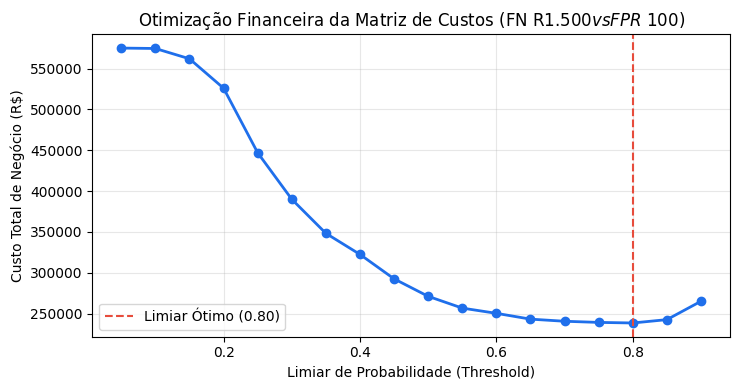

In [11]:
# Solução Demonstrativa do Exercício Prático de Matriz de Custos
y_proba_mlp = mlp_over.predict_proba(X_test_scaled)[:, 1]

custo_fn = 1500  # R$ por fraude perdida
custo_fp = 100   # R$ por falso alarme

thresholds = np.arange(0.05, 0.95, 0.05)
custos_totais = []

for t in thresholds:
    y_pred_t = (y_proba_mlp >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()
    custo_total = (fn * custo_fn) + (fp * custo_fp)
    custos_totais.append(custo_total)

idx_otimo = np.argmin(custos_totais)
threshold_otimo = thresholds[idx_otimo]
custo_minimo = custos_totais[idx_otimo]

print(f"Limiar Ótimo de Decisão: {threshold_otimo:.2f}")
print(f"Custo Total Mínimo no Teste: R$ {custo_minimo:,.2f}")

fig, ax = plt.subplots(figsize=(7.5, 4))
ax.plot(thresholds, custos_totais, marker='o', color='#1F6FEB', linewidth=2)
ax.axvline(threshold_otimo, color='#E74C3C', linestyle='--', label=f'Limiar Ótimo ({threshold_otimo:.2f})')
ax.set_xlabel("Limiar de Probabilidade (Threshold)")
ax.set_ylabel("Custo Total de Negócio (R$)")
ax.set_title("Otimização Financeira da Matriz de Custos (FN R$ 1.500 vs FP R$ 100)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Anexo: Outras Aplicações de Negócio com a Mesma Técnica**

A técnica usada aqui (classificação supervisionada para identificar eventos raros/anômalos, como fraude) se aplica a diversos outros problemas de negócio:

### 1. Finanças e Bancos
- **Detecção de Fraudes em Cartões de Crédito:** identificar transações que fogem do padrão de consumo do cliente.
- **Análise de Risco de Crédito:** detectar comportamentos incomuns em contas que podem indicar risco iminente de inadimplência.

### 2. Cibersegurança
- **Detecção de Ameaças Internas:** identificar funcionários que acessam volumes anormais de dados confidenciais.

### 3. E-commerce e Varejo
- **Identificação de Avaliações Falsas (Fake Reviews):** detectar picos anormais de avaliações geradas por bots.
- **Monitoramento de Erros de Precificação:** alertar rapidamente se um produto for listado com preço errado.

### 4. Saúde
- **Detecção de Fraudes em Seguros de Saúde:** identificar clínicas ou médicos com padrões de cobrança anormais.